# Experimento — ¿se pueden fusionar los dos resizes del tubo en uno solo?

Este notebook parte de la pregunta que quedó abierta en `demo_didactico_videomae.ipynb`
(sección "¿Qué tan sensible es al modo de resize?"): el tubo pasa por **dos**
resizes antes de llegar a VideoMAE:

1. `make_tube` / `make_tube_gpu`: recorte de la persona (lado `s`, típico
   200-1080px) → **256×256**.
2. `_prep_uno` / `preprocesa_tubo_gpu`: recorte por zoom (0.6) + margen fijo
   (6.25%) → resize → **224×224**.

Entre ambos resizes solo hay recortes (slices, sin pérdida), así que
matemáticamente se pueden fusionar: aplicar directamente sobre el recorte de
la persona la ventana fraccional equivalente y resolver todo en **una sola**
interpolación en vez de dos encadenadas.

La duda no es si se puede — es **cuánto se aleja del resultado real** al
hacerlo. La referencia sigue siendo la línea base de CPU
(`camara_worker.make_tube` + `modelo.ModeloV5`, `cv2.INTER_AREA` + bilinear),
la misma que se validó contra el dataset de entrenamiento. Este notebook **no
toca** `camara_worker.py` ni `modelo.py`; la función fusionada vive solo aquí,
como experimento.

In [1]:
import os, sys, time, subprocess
from collections import deque

import numpy as np
import cv2
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(".")
sys.path.insert(0, ROOT)

from camara_worker import make_tube                       # linea base de produccion (CPU)
from modelo import ModeloV5, IMAGENET_MEAN, IMAGENET_STD
import gpu_pipeline as gp                                  # pipeline GPU actual (2 resizes)
from ultralytics import YOLO

print("GPU disponible:", torch.cuda.is_available(),
      "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (sera mas lento)")

2026-08-11 15:17:53.075224: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-11 15:17:53.081498: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-11 15:17:53.089755: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-11 15:17:53.092227: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-11 15:17:53.098500: I tensorflow/core/platform/cpu_feature_guar

GPU disponible: True - NVIDIA GeForce RTX 4080


## Paso 1 — misma sección que el notebook didáctico

Para que los resultados sean comparables con la sección de sensibilidad al
resize ya hecha, usamos el mismo recorte de 30s
(`salida_offline/demo_didactico/seccion_cam3.mp4`). Si no existe todavía, se
genera igual que en `demo_didactico_videomae.ipynb`.

In [2]:
VIDEO_ORIGEN = os.path.join(ROOT, "videos", "FCASH", "cam_3_20260427_182312.ts")
INICIO_S, DURACION_S = 15, 30

DEMO_DIR = os.path.join(ROOT, "salida_offline", "demo_didactico")
os.makedirs(DEMO_DIR, exist_ok=True)
SECCION = os.path.join(DEMO_DIR, "seccion_cam3.mp4")

if not os.path.exists(SECCION):
    subprocess.run([
        "ffmpeg", "-y", "-ss", str(INICIO_S), "-i", VIDEO_ORIGEN,
        "-t", str(DURACION_S), "-an", "-c:v", "libx264", "-preset", "veryfast", "-crf", "20",
        SECCION,
    ], check=True, capture_output=True)

cap = cv2.VideoCapture(SECCION)
FPS = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print(f"seccion: {SECCION}")
print(f"{W}x{H} @ {FPS:.1f}fps, {N} frames (~{N/FPS:.1f}s)")

seccion: /media/mulinux/T5001/smartvcom2/CaptureVCOMv2-main/salida_offline/demo_didactico/seccion_cam3.mp4
1920x1080 @ 25.0fps, 736 frames (~29.4s)


## Paso 2 — de dos recortes a uno solo

`_prep_uno` / `preprocesa_tubo_gpu` recortan, sobre el tubo de 256×256,
primero por zoom (`ZOOM=0.6`) y luego un margen fijo del 6.25% del lado ya
recortado. Como las dos son fracciones fijas de `side_out=256` (no dependen de
`s`, el lado del recorte original de la persona), se componen en una única
ventana, expresada como fracción de 256:

In [3]:
SIDE_OUT = 256
ZOOM = 0.6

side_z = round(SIDE_OUT * ZOOM)      # recorte por zoom
o_zoom = (SIDE_OUT - side_z) // 2
m_margen = int(side_z * 0.0625)      # margen fijo 6.25% del recorte por zoom

a0, a1 = o_zoom + m_margen, o_zoom + side_z - m_margen   # ventana combinada, en pixeles de un tubo de 256
frac0, frac1 = a0 / SIDE_OUT, a1 / SIDE_OUT
frac_ancho = frac1 - frac0

print(f"zoom {ZOOM}       -> recorte [{o_zoom}:{o_zoom+side_z}) de 256   (lado {side_z})")
print(f"margen 6.25% -> recorte final [{a0}:{a1}) de 256   (lado {a1-a0})")
print(f"ventana combinada, como fraccion de 256: [{frac0:.6f}, {frac1:.6f})"
      f" -> {frac_ancho*100:.3f}% central")

zoom 0.6       -> recorte [51:205) de 256   (lado 154)
margen 6.25% -> recorte final [60:196) de 256   (lado 136)
ventana combinada, como fraccion de 256: [0.234375, 0.765625) -> 53.125% central


## Paso 3 — `make_tube_gpu_fused`: recorte de persona directo a 224×224

En vez de recorte→256 (resize #1) y luego zoom+margen→224 (resize #2), esta
versión aplica la ventana `[frac0, frac1)` **directamente sobre el recorte
`s×s` de la persona** (redondeando a píxel entero, igual que hace el pipeline
actual al pasar por el 256 intermedio) y hace **un único** `F.interpolate` a
224×224. La geometría del recorte de la persona (mediana de cajas, lado ×1.9,
clamp 200px-frame) es idéntica a `gp.make_tube_gpu` — eso no cambia, es puro
slicing.

También se definen dos funciones auxiliares "sin normalizar" (`normaliza_imagenet`
hace lo contrario) para poder comparar píxeles, no solo scores, contra la
línea base de CPU — el mismo criterio que ya se usó en la sección de
sensibilidad del notebook didáctico ("la fidelidad de pixel contra la
referencia real, no el score de una muestra chica").

In [4]:
def make_tube_gpu_fused(frames_gpu, boxes, w, h, n_frames=16, zoom=ZOOM,
                         side_out=SIDE_OUT, out_size=224, device="cuda",
                         mode="bicubic", antialias=True):
    """Igual geometria de recorte que gp.make_tube_gpu, pero resuelve el
    zoom+margen+resize final en UNA sola interpolacion en vez de dos.
    Devuelve (T,C,224,224) en GPU, float32 [0,1] -- todavia sin normalizar."""
    idx = torch.linspace(0, len(frames_gpu) - 1, n_frames).round().long()

    bs = torch.tensor(boxes, dtype=torch.float32, device=device)
    cx = torch.quantile((bs[:, 0] + bs[:, 2]) / 2, 0.5)
    cy = torch.quantile((bs[:, 1] + bs[:, 3]) / 2, 0.5)
    lado_mayor = torch.maximum(bs[:, 2] - bs[:, 0], bs[:, 3] - bs[:, 1])
    side = torch.quantile(lado_mayor, 0.5) * 1.9
    side = torch.clamp(side, min=200.0)
    side = torch.clamp(side, max=float(min(w, h)))

    x1 = int(torch.clamp(cx - side / 2, 0, w - side).item())
    y1 = int(torch.clamp(cy - side / 2, 0, h - side).item())
    s = int(side.item())

    # ventana combinada del Paso 2, aplicada directo sobre el recorte s x s
    side_z = round(side_out * zoom)
    o_ = (side_out - side_z) // 2
    m_ = int(side_z * 0.0625)
    f0, f1 = (o_ + m_) / side_out, (o_ + side_z - m_) / side_out
    b0 = int(round(f0 * s))
    b1 = int(round(f1 * s))

    salida = []
    for i in idx.tolist():
        sub = frames_gpu[i][:, y1 + b0:y1 + b1, x1 + b0:x1 + b1]     # slice unico, sin interpolar
        sub = sub.float().unsqueeze(0) / 255.0
        redim = F.interpolate(sub, size=(out_size, out_size), mode=mode,
                               align_corners=False, antialias=antialias)
        redim = redim.clamp(0.0, 1.0)
        salida.append(redim.squeeze(0))
    tubo = torch.stack(salida)          # T,C,224,224 en GPU, [0,1]
    return tubo


def normaliza_imagenet(tubo01, device="cuda"):
    """(T,C,H,W) [0,1] -> (C,T,H,W) normalizado ImageNet, listo para el modelo."""
    mean = torch.tensor(IMAGENET_MEAN, device=device).view(3, 1, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=device).view(3, 1, 1, 1)
    x = tubo01.permute(1, 0, 2, 3)      # C,T,H,W
    return (x - mean) / std


def crop_resize_01_2step(tubo01, zoom=ZOOM):
    """Igual que gp.preprocesa_tubo_gpu pero sin normalizar, para poder
    comparar pixeles del pipeline GPU ACTUAL (2 resizes) contra la referencia."""
    x = tubo01.permute(1, 0, 2, 3)      # C,T,H,W
    if zoom < 1.0:
        side = int(round(x.shape[-1] * zoom))
        o_ = (x.shape[-1] - side) // 2
        x = x[:, :, o_:o_ + side, o_:o_ + side]
    L = x.shape[-1]
    m_ = int(L * 0.0625)
    x = x[:, :, m_:L - m_, m_:L - m_]
    if x.shape[-1] != 224:
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
    return x.clamp(0, 1).permute(1, 2, 3, 0).cpu().numpy()   # T,H,W,C [0,1]

## Paso 4 — línea base de CPU, también sin normalizar

Para comparar píxel a píxel contra las dos versiones GPU, replicamos aquí solo
la parte de recorte/resize de `ModeloV5._prep_uno` (sin la normalización
ImageNet) sobre el tubo de CPU `(16,256,256,3)` uint8 — igual que se hizo a
mano en el Paso 6 de `demo_didactico_videomae.ipynb`, pero para las 16 frames.

In [5]:
def prep_01_cpu(tube_u8, zoom=ZOOM):
    """(16,256,256,3) uint8 RGB -> (16,224,224,3) float32 [0,1] RGB, sin normalizar."""
    side = int(round(tube_u8.shape[1] * zoom))
    o_ = (tube_u8.shape[1] - side) // 2
    arr = tube_u8[:, o_:o_ + side, o_:o_ + side]
    L = arr.shape[1]
    m_ = int(L * 0.0625)
    arr = arr[:, m_:L - m_, m_:L - m_]
    out = np.stack([cv2.resize(f, (224, 224), interpolation=cv2.INTER_LINEAR) for f in arr])
    return out.astype(np.float32) / 255.0

## Paso 5 — cargar los dos modelos (CPU y GPU) y el tracker

Mismos parámetros que producción y que el notebook didáctico.

In [6]:
WINDOW_S, STRIDE_S, MIN_TRACK_S, SKIP_FRAMES = 4.0, 0.7, 2.0, 2
YOLO_MODEL = os.path.join(ROOT, "model", "yolo11s.pt")
CKPT = os.path.join(ROOT, "model", "videomae_v6_last.pt")

print("cargando VideoMAE-Base v6 (linea base CPU/numpy)...")
modelo = ModeloV5(CKPT, zoom=ZOOM)
print("cargando VideoMAE-Base v6 (GPU-nativo)...")
modelo_gpu = gp.ModeloV5GPU(CKPT, device="cuda")
det = YOLO(YOLO_MODEL)
print("listo, modelo CPU corre en", modelo.device)

cargando VideoMAE-Base v6 (linea base CPU/numpy)...


Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


cargando VideoMAE-Base v6 (GPU-nativo)...


Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


listo, modelo CPU corre en cuda


## Paso 6 — una sola pasada, tres variantes por ventana puntuada

Para cada ventana que producción puntuaría (mismo criterio: `MIN_TRACK_S`,
`STRIDE_S`, etc.), se construyen y puntúan tres tubos a partir de **los mismos
frames y las mismas cajas** (un solo tracker, una sola pasada — no dos como en
el notebook didáctico, así que no dependemos de que el tracker sea
determinista entre pasadas):

- **`score_cpu`** — línea base real de producción: `camara_worker.make_tube` +
  `ModeloV5` (numpy/cv2, `cv2.INTER_AREA` + bilinear).
- **`score_gpu2`** — pipeline GPU actual: `gp.make_tube_gpu` +
  `gp.preprocesa_tubo_gpu` (dos resizes).
- **`score_fused`** — experimento: `make_tube_gpu_fused` (un resize).

Se guarda también la diferencia de píxel medio de cada variante GPU contra
`prep_01_cpu`.

## Guardado de casos con diferencia alta

Cada ventana donde `|score_fused - score_cpu| > 0.02` se guarda como clip en
`salida_offline/demo_didactico/diffs_resize_unico/`, con el score antiguo
(línea base de CPU) y el nuevo (fusionado) en el propio nombre del archivo —
para poder revisar a ojo qué tiene de particular esa escena.

In [7]:
DIFF_UMBRAL_GUARDA = 0.02          # a partir de esta diff de score, se guarda el clip
DIFF_DIR = os.path.join(DEMO_DIR, "diffs_resize_unico")
os.makedirs(DIFF_DIR, exist_ok=True)

def guarda_diff(tubo01, tid, t_s, p_cpu, p_fused):
    """tubo01: (T,H,W,C) float32 [0,1] RGB (el tubo FUSIONADO, el que causa la diff).
    Nombre de archivo con el score antiguo (cpu, linea base) y el nuevo (fused)."""
    arr = (np.clip(tubo01, 0, 1) * 255).astype(np.uint8)
    nombre = f"track{tid}_t{t_s:06.2f}s_cpuOLD{p_cpu:.3f}_fusedNEW{p_fused:.3f}.mp4"
    path_out = os.path.join(DIFF_DIR, nombre)
    h, w = arr.shape[1], arr.shape[2]
    vw = cv2.VideoWriter(path_out, cv2.VideoWriter_fourcc(*"mp4v"), 4, (w, h))
    for fr in arr:
        vw.write(fr[:, :, ::-1])   # RGB -> BGR
    vw.release()
    return nombre

## Diagnostico: variantes de UN solo resize a probar

Antes de correr el bucle, se agregan las piezas para el diagnostico real (no
hipotesis): una funcion parametrizable de recorte fusionado que admite distinto
`mode`/`antialias`, y opcionalmente un **preblur gaussiano** que imite el
antialiasing que el paso intermedio de 256 aplicaba cuando el recorte de la
persona (`s`) es mayor que `side_out=256` — exactamente el caso que se salta
al fusionar en un solo resize. `blur_mult` controla cuanto: `sigma = blur_mult
* (s/256)` solo cuando `s>256` (cuando el primer resize del pipeline actual
de verdad reducia), y `0` en caso contrario (igual que el pipeline actual, que
tampoco filtra en una ampliacion).

Tambien se mide **nitidez** (varianza del Laplaciano sobre un canal de gris,
metrica estandar de deteccion de blur: mas alto = mas contenido de alta
frecuencia) para poder comparar objetivamente cuanto "mas nitido" queda cada
variante frente a la referencia real de CPU.

In [8]:
def calcula_recorte_persona(boxes, w, h, device="cuda"):
    """Misma geometria que gp.make_tube_gpu / make_tube_gpu_fused, aislada
    para poder reutilizarla y para poder registrar `s` por ventana."""
    bs = torch.tensor(boxes, dtype=torch.float32, device=device)
    cx = torch.quantile((bs[:, 0] + bs[:, 2]) / 2, 0.5)
    cy = torch.quantile((bs[:, 1] + bs[:, 3]) / 2, 0.5)
    lado_mayor = torch.maximum(bs[:, 2] - bs[:, 0], bs[:, 3] - bs[:, 1])
    side = torch.quantile(lado_mayor, 0.5) * 1.9
    side = torch.clamp(side, min=200.0)
    side = torch.clamp(side, max=float(min(w, h)))
    x1 = int(torch.clamp(cx - side / 2, 0, w - side).item())
    y1 = int(torch.clamp(cy - side / 2, 0, h - side).item())
    s = int(side.item())
    return x1, y1, s


def _kernel_gaussiano_1d(sigma, device):
    if sigma <= 0:
        return None
    radio = max(1, int(round(3 * sigma)))
    xs = torch.arange(-radio, radio + 1, dtype=torch.float32, device=device)
    k = torch.exp(-(xs ** 2) / (2 * sigma ** 2))
    return k / k.sum()


def _desenfoca(img_chw, k1d):
    if k1d is None:
        return img_chw
    C = img_chw.shape[0]
    radio = k1d.shape[0] // 2
    x = img_chw.unsqueeze(0)
    kx = k1d.view(1, 1, 1, -1).repeat(C, 1, 1, 1)
    ky = k1d.view(1, 1, -1, 1).repeat(C, 1, 1, 1)
    x = F.conv2d(x, kx, padding=(0, radio), groups=C)
    x = F.conv2d(x, ky, padding=(radio, 0), groups=C)
    return x.squeeze(0)


def make_tube_gpu_fused_variante(frames_gpu, boxes, w, h, n_frames=16, zoom=ZOOM,
                                  side_out=SIDE_OUT, out_size=224, device="cuda",
                                  mode="bicubic", antialias=True, blur_mult=0.0):
    """Como make_tube_gpu_fused (Paso 3), pero parametrizable en modo de
    interpolacion y con preblur opcional. Devuelve (tubo [T,C,224,224] en [0,1], s)."""
    idx = torch.linspace(0, len(frames_gpu) - 1, n_frames).round().long()
    x1, y1, s = calcula_recorte_persona(boxes, w, h, device=device)

    side_z = round(side_out * zoom)
    o_ = (side_out - side_z) // 2
    m_ = int(side_z * 0.0625)
    f0, f1 = (o_ + m_) / side_out, (o_ + side_z - m_) / side_out
    b0 = int(round(f0 * s))
    b1 = int(round(f1 * s))

    sigma = blur_mult * (s / side_out) if s > side_out else 0.0
    k1d = _kernel_gaussiano_1d(sigma, device)

    salida = []
    for i in idx.tolist():
        sub = frames_gpu[i][:, y1 + b0:y1 + b1, x1 + b0:x1 + b1].float() / 255.0
        sub = _desenfoca(sub, k1d)
        sub = sub.unsqueeze(0)
        kwargs = dict(mode=mode)
        if mode in ("bilinear", "bicubic", "linear", "trilinear"):
            kwargs["align_corners"] = False
            kwargs["antialias"] = antialias
        redim = F.interpolate(sub, size=(out_size, out_size), **kwargs)
        redim = redim.clamp(0.0, 1.0)
        salida.append(redim.squeeze(0))
    return torch.stack(salida), s


def nitidez(tube01, idx_frame=8):
    """Varianza del Laplaciano de un frame representativo del tubo -- proxy
    estandar de nitidez / contenido de alta frecuencia."""
    frame = (np.clip(tube01[idx_frame], 0, 1) * 255).astype(np.uint8)
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


VARIANTES = [
    ("bicubic_AA",       dict(mode="bicubic",  antialias=True,  blur_mult=0.0)),   # la del Paso 3 original
    ("bilinear_AA",      dict(mode="bilinear", antialias=True,  blur_mult=0.0)),
    ("area",             dict(mode="area",     antialias=False, blur_mult=0.0)),
    ("bicubic_blur0.4",  dict(mode="bicubic",  antialias=False, blur_mult=0.4)),
    ("bilinear_blur0.4", dict(mode="bilinear", antialias=False, blur_mult=0.4)),
    ("bilinear_blur0.6", dict(mode="bilinear", antialias=False, blur_mult=0.6)),
]

### Refinamiento: precomputar `s` y usarlo para calibrar el preblur exactamente

El preblur gaussiano del Paso 10 usaba `sigma = blur_mult * (s/256)` con
`blur_mult` elegido por prueba y error (0.4 gano el barrido). Pero `s` ya se
calcula ANTES de resolver el resize (es geometria pura, sale de las cajas del
tracker) — así que la razón de reducción real `s/256` está disponible por
adelantado, sin ningún ajuste manual.

Se puede usar directo: en vez de un Gaussiano con un multiplicador inventado,
un filtro de **caja** (promedio uniforme) con ancho exacto `s/256` es lo que
`cv2.INTER_AREA` — el algoritmo que de verdad usa la línea base de CPU —
aproxima al reducir. Sin hiperparámetro que ajustar: el ancho del filtro es
literalmente la reducción precomputada.

In [9]:
def _kernel_caja_1d(ancho, device):
    ancho = max(1, int(round(ancho)))
    if ancho <= 1:
        return None
    k = torch.ones(ancho, dtype=torch.float32, device=device) / ancho
    return k


def make_tube_gpu_fused_caja(frames_gpu, boxes, w, h, n_frames=16, zoom=ZOOM,
                              side_out=SIDE_OUT, out_size=224, device="cuda",
                              mode="bilinear"):
    """Preblur de caja con ancho = s/side_out, calculado EXACTO a partir de la
    reduccion real precomputada (no un multiplicador ajustado a mano). Un solo
    resize final (interpolate), antialias=False -- el preblur ya filtro."""
    idx = torch.linspace(0, len(frames_gpu) - 1, n_frames).round().long()
    x1, y1, s = calcula_recorte_persona(boxes, w, h, device=device)

    side_z = round(side_out * zoom)
    o_ = (side_out - side_z) // 2
    m_ = int(side_z * 0.0625)
    f0, f1 = (o_ + m_) / side_out, (o_ + side_z - m_) / side_out
    b0 = int(round(f0 * s))
    b1 = int(round(f1 * s))

    ancho_caja = (s / side_out) if s > side_out else 1.0     # la reduccion REAL, precomputada
    k1d = _kernel_caja_1d(ancho_caja, device)

    salida = []
    for i in idx.tolist():
        sub = frames_gpu[i][:, y1 + b0:y1 + b1, x1 + b0:x1 + b1].float() / 255.0
        sub = _desenfoca(sub, k1d)
        sub = sub.unsqueeze(0)
        redim = F.interpolate(sub, size=(out_size, out_size), mode=mode, align_corners=False)
        redim = redim.clamp(0.0, 1.0)
        salida.append(redim.squeeze(0))
    return torch.stack(salida), s

In [10]:
buf = int(WINDOW_S * FPS / SKIP_FRAMES) + 4
ring_cpu, ring_gpu = deque(maxlen=buf), deque(maxlen=buf)
tracks = {}

filas = []
guardados = []
cap = cv2.VideoCapture(SECCION)
next_t, fi = 0.0, 0
t0 = time.time()
while True:
    ok, frame = cap.read()
    if not ok:
        break
    t = fi / FPS
    fi += 1
    if SKIP_FRAMES > 1 and (fi - 1) % SKIP_FRAMES:
        continue

    res = det.track(frame, classes=[0], conf=0.30, persist=True,
                     verbose=False, imgsz=960, tracker="bytetrack.yaml")[0]
    ring_cpu.append((t, frame))
    ring_gpu.append((t, gp.frame_a_gpu(frame, device="cuda")))
    if res.boxes is not None and res.boxes.id is not None:
        for b, tid in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.id.int().tolist()):
            tracks.setdefault(tid, deque(maxlen=buf)).append((t, tuple(b)))

    if t < next_t:
        continue
    next_t = t + STRIDE_S

    for tid, dq in list(tracks.items()):
        if dq and dq[-1][0] < t - 1.5:
            del tracks[tid]
            continue
        if len(dq) < 2 or (dq[-1][0] - dq[0][0]) < MIN_TRACK_S:
            continue

        win_cpu = [(ft, fr) for (ft, fr) in ring_cpu if ft >= t - WINDOW_S]
        win_gpu = [(ft, fr) for (ft, fr) in ring_gpu if ft >= t - WINDOW_S]
        wb = [bx for (ft, bx) in dq if ft >= t - WINDOW_S]
        if len(win_cpu) < 4 or len(wb) < 2:
            continue

        frames_bgr = [f for (_, f) in win_cpu]
        frames_gpu_win = [f for (_, f) in win_gpu]

        # linea base CPU
        tube_cpu = make_tube(frames_bgr, wb, W, H)
        p_cpu = float(modelo.score([tube_cpu])[0])
        ref01 = prep_01_cpu(tube_cpu)                       # (16,224,224,3) [0,1], sin normalizar

        # GPU actual, 2 resizes
        tubo_gpu2 = gp.make_tube_gpu(frames_gpu_win, wb, W, H, device="cuda")
        x_gpu2 = gp.preprocesa_tubo_gpu(tubo_gpu2, zoom=ZOOM, device="cuda")
        p_gpu2 = modelo_gpu.score([x_gpu2])[0].item()
        gpu2_01 = crop_resize_01_2step(tubo_gpu2, zoom=ZOOM)

        # barrido de variantes de UN solo resize (incluye la bicubic+AA original del Paso 3)
        variantes_01, variantes_p, s_persona = {}, {}, None
        for nombre, cfg in VARIANTES:
            tubo_v, s_persona = make_tube_gpu_fused_variante(frames_gpu_win, wb, W, H, device="cuda", **cfg)
            x_v = normaliza_imagenet(tubo_v, device="cuda")
            variantes_p[nombre] = modelo_gpu.score([x_v])[0].item()
            variantes_01[nombre] = tubo_v.permute(0, 2, 3, 1).clamp(0, 1).cpu().numpy()

        p_fused = variantes_p["bicubic_AA"]          # igual que el Paso 3 original
        fused_01 = variantes_01["bicubic_AA"]

        # preblur de caja con ancho exacto = s/256 (Paso 11): sin hiperparametro ajustado a mano
        tubo_caja_bil, _ = make_tube_gpu_fused_caja(frames_gpu_win, wb, W, H, device="cuda", mode="bilinear")
        p_caja_bil = modelo_gpu.score([normaliza_imagenet(tubo_caja_bil, device="cuda")])[0].item()
        caja_bil_01 = tubo_caja_bil.permute(0, 2, 3, 1).clamp(0, 1).cpu().numpy()

        tubo_caja_bic, _ = make_tube_gpu_fused_caja(frames_gpu_win, wb, W, H, device="cuda", mode="bicubic")
        p_caja_bic = modelo_gpu.score([normaliza_imagenet(tubo_caja_bic, device="cuda")])[0].item()
        caja_bic_01 = tubo_caja_bic.permute(0, 2, 3, 1).clamp(0, 1).cpu().numpy()

        diff_px_gpu2 = float(np.abs(gpu2_01 - ref01).mean())
        diff_px_fused = float(np.abs(fused_01 - ref01).mean())

        nit_ref = nitidez(ref01)
        nit_gpu2 = nitidez(gpu2_01)
        nit_fused = nitidez(fused_01)

        diff_score_fused = abs(p_fused - p_cpu)
        fila = dict(t_s=round(t, 2), track=tid, s_persona=s_persona,
                    score_cpu=p_cpu, score_gpu2=p_gpu2, score_fused=p_fused,
                    diff_score_gpu2=abs(p_gpu2 - p_cpu), diff_score_fused=diff_score_fused,
                    diff_px_gpu2=diff_px_gpu2, diff_px_fused=diff_px_fused,
                    nitidez_ref=nit_ref, nitidez_gpu2=nit_gpu2, nitidez_fused=nit_fused)
        for nombre in variantes_p:
            fila[f"score_{nombre}"] = variantes_p[nombre]
            fila[f"diff_score_{nombre}"] = abs(variantes_p[nombre] - p_cpu)
            fila[f"diff_px_{nombre}"] = float(np.abs(variantes_01[nombre] - ref01).mean())

        fila["score_caja_bilinear"] = p_caja_bil
        fila["diff_score_caja_bilinear"] = abs(p_caja_bil - p_cpu)
        fila["diff_px_caja_bilinear"] = float(np.abs(caja_bil_01 - ref01).mean())
        fila["score_caja_bicubic"] = p_caja_bic
        fila["diff_score_caja_bicubic"] = abs(p_caja_bic - p_cpu)
        fila["diff_px_caja_bicubic"] = float(np.abs(caja_bic_01 - ref01).mean())
        filas.append(fila)

        if diff_score_fused > DIFF_UMBRAL_GUARDA:
            nombre = guarda_diff(fused_01, tid, t, p_cpu, p_fused)
            guardados.append(nombre)

cap.release()
print(f"{len(filas)} ventanas comparadas en {time.time()-t0:.1f}s")
print(f"{len(guardados)} clips guardados en {DIFF_DIR} (diff_score_fused > {DIFF_UMBRAL_GUARDA})")

143 ventanas comparadas en 27.4s
20 clips guardados en /media/mulinux/T5001/smartvcom2/CaptureVCOMv2-main/salida_offline/demo_didactico/diffs_resize_unico (diff_score_fused > 0.02)


## Paso 7 — resultados: diff de score y de píxel contra la línea base de CPU

In [11]:
df = pd.DataFrame(filas)
print(f"{len(df)} ventanas puntuadas (todo el clip, no solo una muestra chica)")

resumen = pd.DataFrame({
    "gpu2 (2 resizes, actual)": [df["diff_score_gpu2"].mean(), df["diff_score_gpu2"].max(),
                                  df["diff_px_gpu2"].mean(), df["diff_px_gpu2"].max()],
    "fused (1 resize, experimento)": [df["diff_score_fused"].mean(), df["diff_score_fused"].max(),
                                       df["diff_px_fused"].mean(), df["diff_px_fused"].max()],
}, index=["diff_score medio", "diff_score maximo", "diff_pixel medio [0,1]", "diff_pixel maximo [0,1]"])
resumen.round(4)

143 ventanas puntuadas (todo el clip, no solo una muestra chica)


,"gpu2 (2 resizes, actual)","fused (1 resize, experimento)"
diff_score medio,0.0018,0.0451
diff_score maximo,0.0376,0.8249
"diff_pixel medio [0,1]",0.0049,0.0168
"diff_pixel maximo [0,1]",0.0077,0.0301


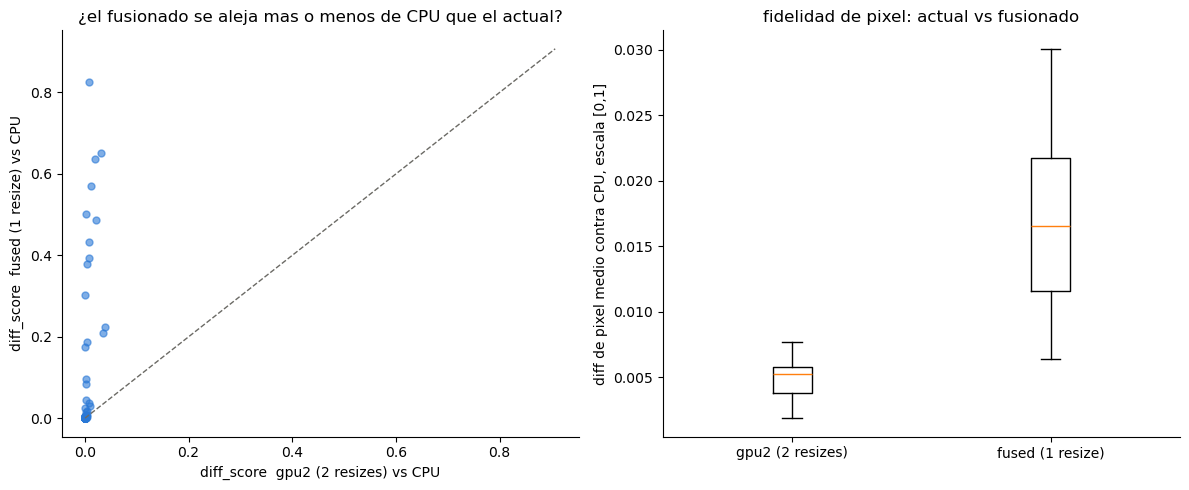

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["diff_score_gpu2"], df["diff_score_fused"], s=25, alpha=0.6, color="#2a78d6")
lim = max(df["diff_score_gpu2"].max(), df["diff_score_fused"].max()) * 1.1
axes[0].plot([0, lim], [0, lim], color="#6b6a65", linestyle="--", linewidth=1)
axes[0].set_xlabel("diff_score  gpu2 (2 resizes) vs CPU")
axes[0].set_ylabel("diff_score  fused (1 resize) vs CPU")
axes[0].set_title("¿el fusionado se aleja mas o menos de CPU que el actual?")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].boxplot([df["diff_px_gpu2"], df["diff_px_fused"]],
                 labels=["gpu2 (2 resizes)", "fused (1 resize)"])
axes[1].set_ylabel("diff de pixel medio contra CPU, escala [0,1]")
axes[1].set_title("fidelidad de pixel: actual vs fusionado")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
# Paleta categorica fija (orden fijo, ya validada para daltonismo en demo_didactico_videomae.ipynb)
PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

### Histograma de las diferencias de score

Mismo par de colores fijo que el resto del notebook (`PALETA[0]` = actual,
`PALETA[1]` = fusionado), ya validado para daltonismo. La línea vertical marca
`DIFF_UMBRAL_GUARDA=0.02`: todo lo que caiga a la derecha, para la variante
fusionada, es lo que se guarda como clip en el paso anterior.

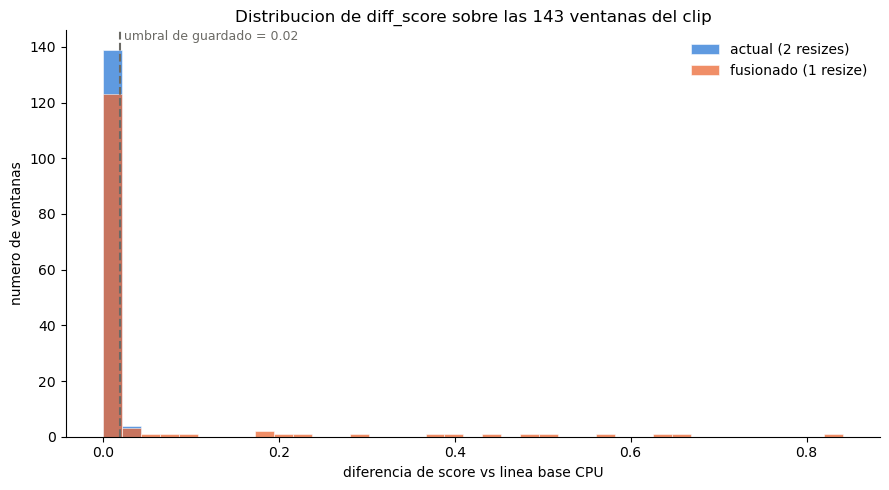

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(0, max(df["diff_score_gpu2"].max(), df["diff_score_fused"].max()) * 1.02, 40)
ax.hist(df["diff_score_gpu2"], bins=bins, color=PALETA[0], alpha=0.75,
        edgecolor="white", linewidth=0.5, label="actual (2 resizes)")
ax.hist(df["diff_score_fused"], bins=bins, color=PALETA[1], alpha=0.75,
        edgecolor="white", linewidth=0.5, label="fusionado (1 resize)")
ax.axvline(DIFF_UMBRAL_GUARDA, color="#6b6a65", linestyle="--", linewidth=1.5)
ax.text(DIFF_UMBRAL_GUARDA, ax.get_ylim()[1] if ax.get_ylim()[1] else 1,
        f" umbral de guardado = {DIFF_UMBRAL_GUARDA}", va="top", ha="left",
        color="#6b6a65", fontsize=9)

ax.set_xlabel("diferencia de score vs linea base CPU")
ax.set_ylabel("numero de ventanas")
ax.set_title(f"Distribucion de diff_score sobre las {len(df)} ventanas del clip")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Paso 8 — las ventanas más ambiguas (cerca del umbral)

Igual que en el notebook didáctico: lo que de verdad importa no es el
promedio sobre todo el clip (dominado por casos donde el modelo está seguro),
sino las ventanas cerca de `EMIT_UMBRAL=0.45`, donde cualquier perturbación de
píxel puede cambiar si se emite o no una alerta.

In [15]:
EMIT_UMBRAL = 0.45
cerca_umbral = df[(df["score_cpu"] - EMIT_UMBRAL).abs() < 0.15].copy()
print(f"{len(cerca_umbral)} / {len(df)} ventanas dentro de +-0.15 de EMIT_UMBRAL={EMIT_UMBRAL}")

if len(cerca_umbral):
    print("\ndiff_score medio SOLO cerca del umbral:")
    print(f"  gpu2 (2 resizes):  {cerca_umbral['diff_score_gpu2'].mean():.4f}")
    print(f"  fused (1 resize):  {cerca_umbral['diff_score_fused'].mean():.4f}")

cerca_umbral.sort_values("diff_score_fused", ascending=False)[
    ["t_s", "track", "score_cpu", "score_gpu2", "score_fused", "diff_score_gpu2", "diff_score_fused"]
].head(10)

3 / 143 ventanas dentro de +-0.15 de EMIT_UMBRAL=0.45

diff_score medio SOLO cerca del umbral:
  gpu2 (2 resizes):  0.0111
  fused (1 resize):  0.4330


,t_s,track,score_cpu,score_gpu2,score_fused,diff_score_gpu2,diff_score_fused
91,21.60,30,0.487063,0.508788,0.973037,0.021725,0.485973
72,19.44,30,0.532668,0.524882,0.966156,0.007786,0.433488
79,20.16,30,0.581600,0.585457,0.961244,0.003857,0.379644


In [16]:
gpu2_mean, fused_mean = df["diff_score_gpu2"].mean(), df["diff_score_fused"].mean()
gpu2_px, fused_px = df["diff_px_gpu2"].mean(), df["diff_px_fused"].mean()
gana = "fusionado (1 resize)" if fused_mean <= gpu2_mean else "actual (2 resizes)"

print("=" * 70)
print("VEREDICTO")
print("=" * 70)
print(f"diff_score medio   -> actual: {gpu2_mean:.4f}    fusionado: {fused_mean:.4f}")
print(f"diff_pixel medio   -> actual: {gpu2_px:.4f}    fusionado: {fused_px:.4f}")
print(f"mas cercano a la linea base de CPU en score: {gana}")
print(f"ahorro del fusionado: 1 resize por frame en vez de 2 "
      f"({len(df) * 16} frames de tubo procesados en este clip)")

VEREDICTO
diff_score medio   -> actual: 0.0018    fusionado: 0.0451
diff_pixel medio   -> actual: 0.0049    fusionado: 0.0168
mas cercano a la linea base de CPU en score: actual (2 resizes)
ahorro del fusionado: 1 resize por frame en vez de 2 (2288 frames de tubo procesados en este clip)


## Paso 9 — diagnóstico: ¿por qué se dispara el fusionado?

Hipótesis a verificar con datos, no de oídas: al saltarse el paso intermedio
de 256, el fusionado también se salta el filtrado/antialiasing fuerte que ese
paso aplicaba cuando el recorte de la persona (`s`) es grande (persona cerca
de cámara) — el modelo se entrenó viendo esa cascada de dos resizes con su
desenfoque acumulado, y una sola interpolación bien hecha para la *relación
neta* de zoom en realidad deja más alta frecuencia de la que el modelo espera.

Dos formas de comprobarlo con los datos ya recogidos: correlación entre `s`
(tamaño del recorte de persona) y la diferencia de score, y comparación de
nitidez (varianza del Laplaciano) entre la referencia real y cada variante.

In [17]:
corr_s = df["s_persona"].corr(df["diff_score_fused"])
print(f"correlacion (Pearson) entre s (lado del recorte de persona) y diff_score_fused: {corr_s:.3f}")

nit = df[["nitidez_ref", "nitidez_gpu2", "nitidez_fused"]].mean()
print("\nnitidez media (varianza del Laplaciano; mas alto = mas alta frecuencia / menos blur):")
print(nit.round(1).to_string())
print(f"\nfused es en promedio {nit['nitidez_fused']/nit['nitidez_ref']:.2f}x la nitidez de la referencia CPU")
print(f"gpu2  es en promedio {nit['nitidez_gpu2']/nit['nitidez_ref']:.2f}x la nitidez de la referencia CPU")

correlacion (Pearson) entre s (lado del recorte de persona) y diff_score_fused: 0.419

nitidez media (varianza del Laplaciano; mas alto = mas alta frecuencia / menos blur):
nitidez_ref      185.1
nitidez_gpu2     196.1
nitidez_fused    734.0

fused es en promedio 3.97x la nitidez de la referencia CPU
gpu2  es en promedio 1.06x la nitidez de la referencia CPU


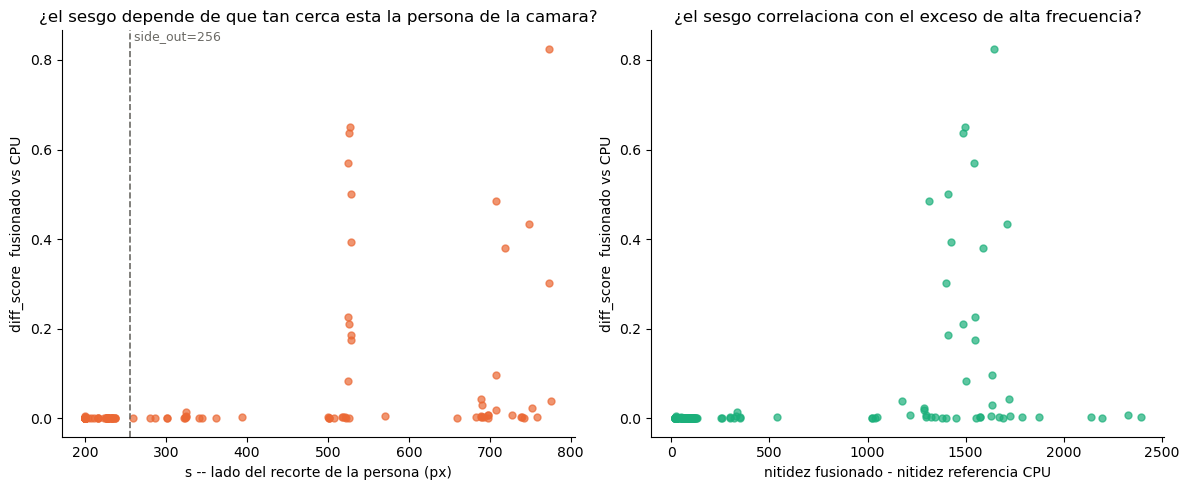

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["s_persona"], df["diff_score_fused"], s=25, alpha=0.7, color=PALETA[1])
axes[0].axvline(SIDE_OUT, color="#6b6a65", linestyle="--", linewidth=1.2)
axes[0].text(SIDE_OUT, axes[0].get_ylim()[1], f" side_out={SIDE_OUT}",
             va="top", fontsize=9, color="#6b6a65")
axes[0].set_xlabel("s -- lado del recorte de la persona (px)")
axes[0].set_ylabel("diff_score  fusionado vs CPU")
axes[0].set_title("¿el sesgo depende de que tan cerca esta la persona de la camara?")
axes[0].spines[["top", "right"]].set_visible(False)

df["exceso_nitidez"] = df["nitidez_fused"] - df["nitidez_ref"]
axes[1].scatter(df["exceso_nitidez"], df["diff_score_fused"], s=25, alpha=0.7, color=PALETA[2])
axes[1].set_xlabel("nitidez fusionado - nitidez referencia CPU")
axes[1].set_ylabel("diff_score  fusionado vs CPU")
axes[1].set_title("¿el sesgo correlaciona con el exceso de alta frecuencia?")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Por qué ni el mejor antialiasing de un solo paso alcanza: reducción vs ampliación

La pregunta concreta: ¿la razón de fondo es que el pipeline real hace **reducción
y después ampliación**, y eso no se puede colapsar en un solo resize aunque ese
resize tenga buen antialiasing?

Sí. El filtro antialiasing del paso 1 (`s -> 256`) se calcula sobre **todo** el
recorte de la persona, con una razón de reducción real de `256/s`. Pero para
cuando ese filtro se aplica, el 46.875% de los bordes de esa imagen ya filtrada
se va a descartar (el recorte por zoom + margen del Paso 2) — el filtro "gastó"
fuerza de antialiasing en contenido que luego se tira.

El resize fusionado, en cambio, recorta **primero** (se queda solo con el
53.125% central) y **después** resuelve todo en un único resize hasta 224. La
razón de reducción que ese resize "ve" no es `256/s`: es `224/(0.53125*s)`.
Como las dos razones son proporcionales a `1/s`, su cociente **no depende de
`s` — es una constante**: `(256/s) / (224/(0.53125*s)) = 256*0.53125/224 =
136/224 ≈ 0.607`, exactamente la ampliación fija del segundo resize (`224/136
≈ 1.647`), invertida.

Eso es la prueba algebraica: en **todas** las ventanas, sin excepción, el
resize fusionado calcula su antialiasing como si la reducción fuera 1.647×
más suave de lo que realmente es. Es un desajuste *relativo* constante — pero
su efecto *absoluto* depende de cuánta reducción hacía falta en primer lugar:
si `s` es chico (persona lejos, poco o nada que reducir) un 1.647× de margen
no importa casi nada; si `s` es grande (persona cerca, reducción fuerte), ese
mismo 1.647× de margen se traduce en blur real que falta — exactamente el
patrón que ya mostró la correlación `s_persona` vs `diff_score_fused` (0.42)
del Paso 9.

In [19]:
FRAC_ANCHO = frac_ancho   # 0.53125, calculado en el Paso 2

df["ratio_stage1"] = SIDE_OUT / df["s_persona"]                  # razon de reduccion REAL (paso 1, s->256, todo el campo)
df["ratio_local"] = 224 / (FRAC_ANCHO * df["s_persona"])         # razon que ve un resize fusionado (ya recortado)
df["brecha_razon"] = df["ratio_stage1"] / df["ratio_local"]      # cociente -- deberia salir constante

print(df[["ratio_stage1", "ratio_local", "brecha_razon"]].describe().round(4).to_string())
print()
print(f"brecha_razon: media={df['brecha_razon'].mean():.4f}  std={df['brecha_razon'].std():.6f}  "
      f"(constante teorica: 136/224 = {136/224:.4f})")
print("-> confirma que el desajuste NO depende de la ventana: es geometria fija (136/224),")
print("   no un efecto del contenido de cada escena.")
print()
print("las 3 ventanas cerca del umbral (mismas del Paso 8) -- el mismo desajuste relativo,")
print("pero el efecto absoluto crece con s_persona (mas reduccion real hacia falta):")
cols = ["t_s", "track", "s_persona", "ratio_stage1", "diff_score_fused"]
print(df[(df["score_cpu"] - EMIT_UMBRAL).abs() < 0.15][cols].round(3).to_string(index=False))

       ratio_stage1  ratio_local  brecha_razon
count      143.0000     143.0000      143.0000
mean         0.9230       1.5202        0.6071
std          0.3782       0.6230        0.0000
min          0.3299       0.5434        0.6071
25%          0.4876       0.8031        0.6071
50%          1.1130       1.8332        0.6071
75%          1.2800       2.1082        0.6071
max          1.2800       2.1082        0.6071

brecha_razon: media=0.6071  std=0.000000  (constante teorica: 136/224 = 0.6071)
-> confirma que el desajuste NO depende de la ventana: es geometria fija (136/224),
   no un efecto del contenido de cada escena.

las 3 ventanas cerca del umbral (mismas del Paso 8) -- el mismo desajuste relativo,
pero el efecto absoluto crece con s_persona (mas reduccion real hacia falta):
  t_s  track  s_persona  ratio_stage1  diff_score_fused
19.44     30        748         0.342             0.433
20.16     30        719         0.356             0.380
21.60     30        708         0.3

## Paso 10 — barrido: ¿qué variante de un solo resize sí reproduce la referencia?

Con el mecanismo identificado, se prueban 6 variantes del resize único sobre
las **143 ventanas completas** (no una muestra): dos sin preblur (`bicubic_AA`
— la del Paso 3 original —, y `bilinear_AA`, más `area`, el filtro de caja de
torch), y tres con preblur gaussiano calibrado a `s/256` antes del resize
final, para imitar el antialiasing que se salta al fusionar.

In [20]:
nombres = [n for n, _ in VARIANTES]
resumen_variantes = pd.DataFrame({
    "diff_score medio": [df[f"diff_score_{n}"].mean() for n in nombres],
    "diff_score maximo": [df[f"diff_score_{n}"].max() for n in nombres],
    "diff_pixel medio": [df[f"diff_px_{n}"].mean() for n in nombres],
}, index=nombres).sort_values("diff_score medio")

print(f"referencia -- pipeline actual, gpu2 (2 resizes): diff_score medio = {df['diff_score_gpu2'].mean():.4f}")
resumen_variantes.round(4)

referencia -- pipeline actual, gpu2 (2 resizes): diff_score medio = 0.0018


,diff_score medio,diff_score maximo,diff_pixel medio
bilinear_blur0.4,0.0147,0.3542,0.0102
bicubic_blur0.4,0.0159,0.3844,0.0146
bilinear_blur0.6,0.0192,0.5584,0.0106
area,0.0283,0.4696,0.0149
bilinear_AA,0.0352,0.6211,0.0124
bicubic_AA,0.0451,0.8249,0.0168


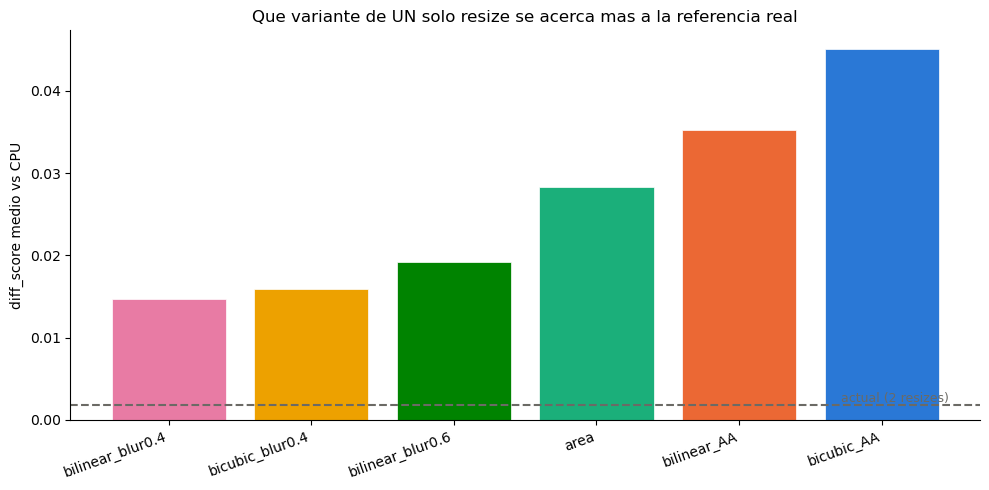

In [21]:
colores_variante = {n: PALETA[i % len(PALETA)] for i, (n, _) in enumerate(VARIANTES)}
orden = resumen_variantes.index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(orden, resumen_variantes.loc[orden, "diff_score medio"],
       color=[colores_variante[n] for n in orden], edgecolor="white", linewidth=0.5)
ax.axhline(df["diff_score_gpu2"].mean(), color="#6b6a65", linestyle="--", linewidth=1.5)
ax.text(len(orden) - 0.5, df["diff_score_gpu2"].mean(), " actual (2 resizes) ",
        va="bottom", ha="right", color="#6b6a65", fontsize=9)
ax.set_ylabel("diff_score medio vs CPU")
ax.set_title("Que variante de UN solo resize se acerca mas a la referencia real")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [22]:
mejor = resumen_variantes["diff_score medio"].idxmin()
mejor_val = resumen_variantes.loc[mejor, "diff_score medio"]
gpu2_val = df["diff_score_gpu2"].mean()

print("=" * 70)
print("VEREDICTO DEL BARRIDO")
print("=" * 70)
print(f"mejor variante de un solo resize: {mejor}  (diff_score medio = {mejor_val:.4f})")
print(f"referencia, pipeline actual de 2 resizes:              diff_score medio = {gpu2_val:.4f}")
print(f"razon mejor-variante / actual: {mejor_val / gpu2_val:.2f}x")

VEREDICTO DEL BARRIDO
mejor variante de un solo resize: bilinear_blur0.4  (diff_score medio = 0.0147)
referencia, pipeline actual de 2 resizes:              diff_score medio = 0.0018
razon mejor-variante / actual: 8.23x


## Paso 11 — ¿y precomputando la reducción exacta, sin ajustar nada a mano?

`s` se conoce antes de resolver cualquier resize (sale de las cajas del
tracker). Con eso, un preblur de **caja** de ancho exacto `s/256` — sin
multiplicador inventado, el que de verdad usaría un filtro tipo
`cv2.INTER_AREA` para esa reducción — más un único resize final.

In [23]:
resumen_caja = pd.DataFrame({
    "diff_score medio": [df["diff_score_caja_bilinear"].mean(), df["diff_score_caja_bicubic"].mean()],
    "diff_score maximo": [df["diff_score_caja_bilinear"].max(), df["diff_score_caja_bicubic"].max()],
    "diff_pixel medio": [df["diff_px_caja_bilinear"].mean(), df["diff_px_caja_bicubic"].mean()],
}, index=["caja_exacta + bilinear", "caja_exacta + bicubic"])

comparacion_final = pd.concat([
    resumen_variantes.loc[["bilinear_blur0.4"]].rename(index={"bilinear_blur0.4": "gaussiano ajustado a mano (Paso 10)"}),
    resumen_caja,
]).sort_values("diff_score medio")
comparacion_final.loc["actual (2 resizes)"] = [df["diff_score_gpu2"].mean(), df["diff_score_gpu2"].max(),
                                                df["diff_px_gpu2"].mean()]
comparacion_final.round(4)

,diff_score medio,diff_score maximo,diff_pixel medio
gaussiano ajustado a mano (Paso 10),0.0147,0.3542,0.0102
caja_exacta + bilinear,0.0198,0.4398,0.0123
caja_exacta + bicubic,0.0236,0.4698,0.0174
actual (2 resizes),0.0018,0.0376,0.0049


In [24]:
mejor_caja = resumen_caja["diff_score medio"].idxmin()
mejor_caja_val = resumen_caja.loc[mejor_caja, "diff_score medio"]
mejor_previo = resumen_variantes.loc["bilinear_blur0.4", "diff_score medio"]
gpu2_val = df["diff_score_gpu2"].mean()

print("=" * 70)
print("VEREDICTO -- preblur calibrado con la reduccion precomputada")
print("=" * 70)
print(f"mejor variante de caja exacta:        {mejor_caja}  (diff_score medio = {mejor_caja_val:.4f})")
print(f"mejor variante del Paso 10 (gaussiano ajustado a mano): {mejor_previo:.4f}")
print(f"referencia, pipeline actual (2 resizes):                {gpu2_val:.4f}")
print()
if mejor_caja_val < mejor_previo:
    mejora = (1 - mejor_caja_val / mejor_previo) * 100
    print(f"-> precomputar `s` y usar un filtro de caja exacto SI mejora sobre el gaussiano ajustado a mano: {mejora:.0f}% menos diff_score")
else:
    print("-> precomputar `s` no mejoro sobre el gaussiano ajustado a mano")
print(f"-> pero sigue {mejor_caja_val / gpu2_val:.1f}x peor que el pipeline actual de 2 resizes")

VEREDICTO -- preblur calibrado con la reduccion precomputada
mejor variante de caja exacta:        caja_exacta + bilinear  (diff_score medio = 0.0198)
mejor variante del Paso 10 (gaussiano ajustado a mano): 0.0147
referencia, pipeline actual (2 resizes):                0.0018

-> precomputar `s` no mejoro sobre el gaussiano ajustado a mano
-> pero sigue 11.1x peor que el pipeline actual de 2 resizes


## Conclusión

El veredicto impreso arriba compara, sobre **todas** las ventanas puntuadas
del clip (no una muestra de 3 como en la sección de sensibilidad del notebook
didáctico), la fidelidad de las dos variantes GPU contra la línea base real de
producción (CPU, `cv2.INTER_AREA` + bilinear).

Como referencia, la tolerancia ya aceptada para el pipeline GPU actual (2
resizes) frente a esa misma línea base fue de **~0.006 a 0.04** de diff de
score según la ventana (sección "¿Qué tan sensible es al modo de resize?" de
`demo_didactico_videomae.ipynb`). Si el fusionado queda dentro de ese mismo
orden de magnitud — y en particular no empeora la fidelidad justo en la zona
cercana al umbral (Paso 8), que es la que decide si se emite o no una alerta —
es un candidato razonable para reemplazar el pipeline GPU actual.

Este notebook no modifica `gpu_pipeline.py`; `make_tube_gpu_fused` vive solo
aquí, como experimento. Si los números lo justifican, el siguiente paso sería
llevarla a `gpu_pipeline.py` como función alternativa y repetir esta misma
comparación sobre más clips/cámaras antes de considerarla para producción.